#### Need to fix this whole code. "padding data" function is used to automate the whole ffa algorithm in  a way that user only supplies with input data and period to fold.  Rest of the things are automatically being done by the code. Since i wrote padding function at last, now i need to start from there and then check the output of other functions serially. Next things to fix on this project

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import mode

## Main Code

In [2]:
def data_munging(raw_data, resolution, test_period):
    
    '''
    This function is important first step in preparing data for folding. It takes input data and modifies it so
    as to meet the criterion required by FFA folding algorithm, especially, the requirement that "np.log2(N/P0)"
    is an integer number. 
    
    '''
    N = len(raw_data)
    delta_t = resolution
    total_time = N*delta_t
    
    if delta_t == 0:
        raise ValueError("Data resolution can't be zero")
    
#     print("\nData resolution", delta_t)
    n_sample = np.rint(test_period/delta_t)
    
    if (test_period<delta_t or test_period > total_time/2):
        raise ValueError("Test period must be greater than data resolution or it can't be greater than half" 
                         "the total time.")
    
    k_factor = math.ceil(np.log2(N/n_sample))
    m_rows = 2**k_factor
    n_cols = n_sample
    N_modified = m_rows*n_cols
    
    if (N_modified != N):    
        zeropad_len = abs(N_modified - N)         
        concat_data = np.concatenate((raw_data, np.zeros(int(zeropad_len))))
        input_data = concat_data.reshape(int(m_rows), int(n_cols))
    else:
        input_data = raw_data
    
    increment_step = np.arange(0, input_data.shape[0]) 
    P_samples = n_sample + (n_sample/(N_modified - n_sample))*increment_step
    P_secs = P_samples*delta_t
    return n_sample, P_secs, k_factor, input_data

In [3]:
def data_munging_downscale(tst_data, resolution, tst_p):
    
    '''
    This function is only different from above 'data_munging' function for the reason that this will trim
    the size of data instead of zeropadding to meet the requirement that "np.log2(N/P0)" is an integer number. 
    
    '''

    N = len(tst_data)
    delta_t = resolution  # Data resolution is sampling rate of data. Can be calculated
    time_T = N*delta_t                            # From time series data. 

    if delta_t == 0:
        raise ValueError("Data resolution can't be zero")
    
    n_sample = np.rint(tst_p/delta_t)
    
    if (tst_p<delta_t or tst_p > time_T/2):
        raise ValueError("Test period must be greater than data resolution or it can't be greater than half" 
                         "the total time.")
    
    n_sample = np.rint(tst_p/delta_t)
    k_factor = math.ceil(np.log2(N/n_sample)) - 1
    m_rows = 2**k_factor
    n_cols = n_sample
    N_modified = m_rows*n_cols
    
    if (N_modified != N):    
#         zeropad_len = abs(N_modified - N)         
        dwnsmpld_dat = tst_data[0:int(N_modified)]
        input_data = dwnsmpld_dat.reshape(int(m_rows), int(n_cols))
    else:
        input_data = tst_data
    
    increment_step = np.arange(0, input_data.shape[0]) 
    P_samples = n_sample + (n_sample/(N_modified - n_sample))*increment_step
    P_secs = P_samples*delta_t
    return n_sample, P_secs, k_factor, input_data

In [4]:
def stage_array(stage_num, n_rows):
    '''
    This function will calculate an array required at each stage to do top-down and bottom-up transform
    operation. For bottom-up operation we will have to use a reversed array output by this function.
    '''
    stage_array_length = 2**(stage_num-1)
    repeat_ind = np.repeat(np.arange(1,stage_array_length), 2)
    base_array = np.concatenate(([0], repeat_ind, [stage_array_length]))
    stretch_factor = n_rows/len(base_array)
    base_array_ext = np.tile(base_array, int(stretch_factor))
    return base_array_ext

In [5]:
def rotation_indices(data_array, n_stage):
    
    ''' This function will create a matrix with its elements incidicating indices by which we will rotate the 
    data array to do the folding later.'''
    
    r_ind = data_array.shape[0]
    base_indx = -1*stage_array(n_stage, r_ind) # Getting shifting array indices from stage_array function.
    col_dim = data_array.shape[1]      # No of columns in data_arr
    r_mat = np.arange(col_dim)      # Creates horizontal array with elements ranging from 0 to col_dim
    c_mat = base_indx[:, None]       # Will take shift_arra
    col_indx = (r_mat - c_mat)%col_dim  # Creates column indices needed to perform rotation
    row_indx = np.arange(data_array.shape[0])[:, None] # Creates row indices needed to perform rotation
    return row_indx, col_indx

In [6]:
def exclude_peak(data):
    M, N = data.shape
    k = int(0.10 * N)   # 10% of columns

    means = np.zeros(M)
    medians = np.zeros(M)
    std_dvn = np.zeros(M)
    for i in range(M):
        row = data[i]

        # peak position in this row
        peak_idx = np.argmax(row)

        # safe bounds to trim
        left  = max(0, peak_idx - k)
        right = min(N, peak_idx + k + 1)

        # trimmed row
        trimmed = np.concatenate((row[:left], row[right:]))

        if trimmed.size == 0:
            means[i] = 0
            medians[i] = 0
            std_dvn[i] = 0
        else:
            means[i] = np.mean(trimmed)
            medians[i] = np.median(trimmed)
            std_dvn[i] = np.std(trimmed)

    return means, medians, std_dvn

In [7]:
def SNR_Cameron_median(final_output_data):
    
    '''
    Will use Cameron et al formula but I_med replaced with Iav to calculate SNR as:  S/N = (Imax - Iav)/std_dev
    '''
    mean, median, std_dvn = exclude_peak(final_output_data)
#     median = np.median(final_output_data, axis=1)
#     std_devn = np.std(final_output_data, axis=1)
    max_values = np.max(final_output_data, axis = 1)
    SNR_values = (max_values - median)/std_dvn
    idx = np.argpartition(SNR_values, -1)[-1:]
    max_2_val = SNR_values[idx]
    return idx[0], max_2_val[0]

In [8]:
def ffa_transform(data_arr, stage_ind):
    
    '''This function performs the actual folding of data at each stage and it does so in two step. First step
    is to create a left hand side array and right hand side array that has been created based on 
    "top_down_trans_ind" and "btm_up_trans_ind"  below. Next step is to add these two arrays. '''
    
    p0 = data_arr.shape[0]
    data_row_ind = np.arange(0, p0)
    base_arr_ind =  stage_array(stage_ind,p0)
    
    # First we do top down transformation
    top_down_trans_ind = data_row_ind - base_arr_ind
    top_down_arr = data_arr.copy()
    top_down_arr[data_row_ind] = data_arr[top_down_trans_ind]
    
    # Second we do bottom up tansformation
    btm_up_trans_ind = data_row_ind + base_arr_ind[::-1]
    btm_up_arr = data_arr.copy()
    btm_up_arr[data_row_ind] = btm_up_arr[btm_up_trans_ind]
    i_row, j_col = rotation_indices(data_arr, stage_ind)
    btm_up_array = btm_up_arr[i_row, j_col]
    stage_output_array = top_down_arr + btm_up_array
    return stage_output_array

In [9]:
def ffa_fold(dataraw, kfactor):
    data_to_fold = dataraw
    for k in range(0, int(kfactor)):
        stage_number = k + 1
        output_data = ffa_transform(data_to_fold, stage_number)
        data_to_fold = output_data
    idx1, snr_score = SNR_Cameron_median(data_to_fold)
    return idx1, snr_score

In [10]:
def mockdata_creator(trial_p, resolution):
    noise_data = 0.05*abs(np.random.randn(100000)) + 0.5
    amplification_factor = 2
    test_signal = noise_data.copy()
    interval = np.rint(trial_p/resolution)
    test_signal[0::int(interval)]+=0.2
    return test_signal

In [11]:
def ffa_alg_launch(test_signal, file_name, dat_res, p_low, p_high):
       
    with open(file_name, 'w') as file:
        file.write("time\t\tSNR_value\n")
        while p_low<=p_high:
            base_P0, range_p, num_stg, data_procsd = data_munging_downscale(test_signal,dat_res, p_low)
            indx1, sig_N_rat = ffa_fold(data_procsd, num_stg)
            best_p = range_p[indx1]
            file.write(f"{best_p}\t\t{sig_N_rat}\n")
            p_low = range_p[-1] 


In [12]:
def periodogram_maker(true_P, prd_dat, snr_dat, save_result):
    
    pulsar_period = prd_dat
    sig_amplitude = snr_dat
    max_ind = np.argmax(sig_amplitude) # Extracting the index for highest SNR value from the result
    min_ind = np.argmin(sig_amplitude)
    fig, periodgram = plt.subplots(figsize=(15,12))
    periodgram.plot(pulsar_period, sig_amplitude,'b')
    periodgram.set_xlabel('Time(sec)', fontweight = 'bold', fontsize = 14)
    periodgram.set_ylabel('SNR', fontweight = 'bold', fontsize = 14)
    periodgram.set_title('Periodgram for '+str(true_P), fontweight = 'bold', fontsize = 14)
    periodgram.text(0.10,0.95,"True period: "+str(true_P)+"s",transform= periodgram.transAxes, fontweight='bold',fontsize=14)
    periodgram.text(0.55,0.95,"Predicted period I: "+str(np.round(pulsar_period[max_ind],4))+"s",transform= periodgram.transAxes, fontweight='bold',fontsize=14)
    periodgram.text(0.55,0.90,"Predicted period II: "+str(np.round(pulsar_period[min_ind],4))+"s",transform= periodgram.transAxes, fontweight='bold',fontsize=14)
    fig.savefig(save_result+"figure_" + str(true_P) + ".pdf")

In [13]:
def grab_actual_period(data_path):
    with open(data_path, 'r') as file:
            actual_period = np.round(float(file.read().split()[0].split('_')[1]),5)
    return actual_period

In [14]:
def read_datafile(file_path):
    df_sim = pd.read_csv(file_path, skiprows=0, sep='\t\t')
    min_dat_point = np.min(df_sim['intensity'])
    resn = df_sim['time'][1] - df_sim['time'][0]
    tst_data = np.array(df_sim['intensity']) - min_dat_point
    return tst_data, resn

In [15]:
def grab_predictedperiod(result_file):
    df3 = pd.read_csv(result_file, skiprows=0, sep='\t\t')
    df3.head(1)
    max_snrval = np.argsort(df3['SNR_value'])[-1:][::-1]
    minn_snrval = np.argsort(df3['SNR_value'])[:1][::-1]
    snrlist = np.concatenate((max_snrval, minn_snrval))
    return np.round(df3['time'][snrlist[0]], 5), np.round(df3['time'][snrlist[1]], 5)

### Reading given data from the direcotry

### Testing with EF's simulated data

For the sake of testing the simulated data EF has given, just look the data file and change the actual period below corresponding to the timeseries data you are testing. This will not be the case in real pulsar data as we do not know the actual period before hand. Here it's just for aesthetic purpose only to put the actual period value in the test data graph so that it can be compared with predicted value in the periodogram. 

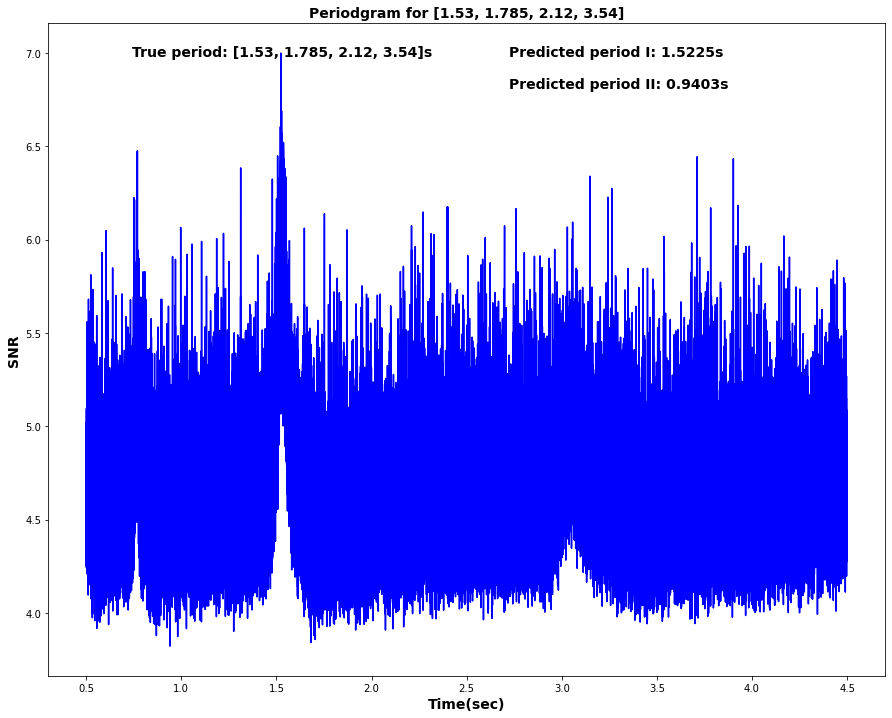

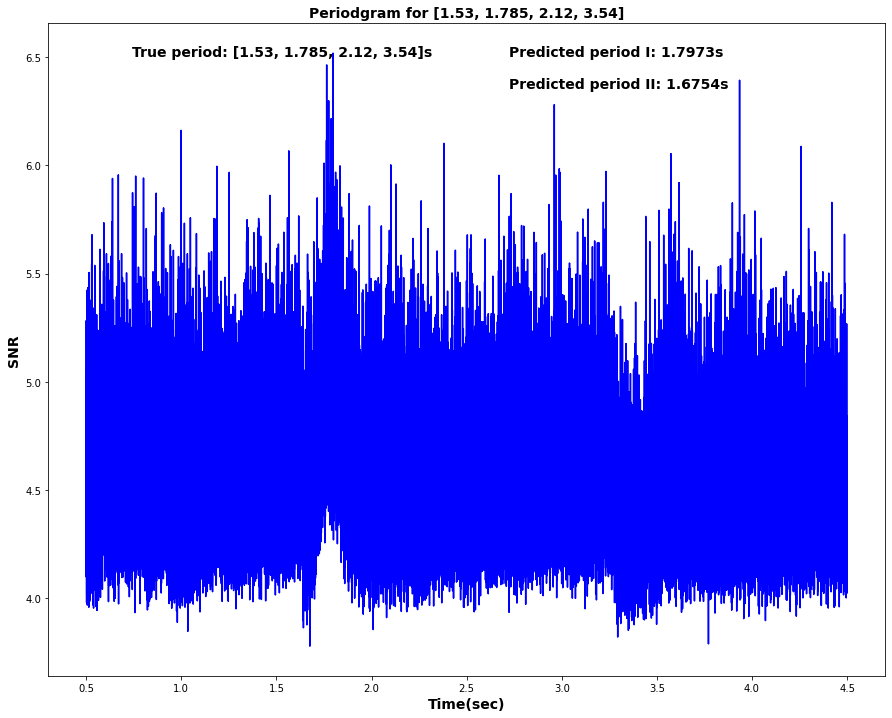

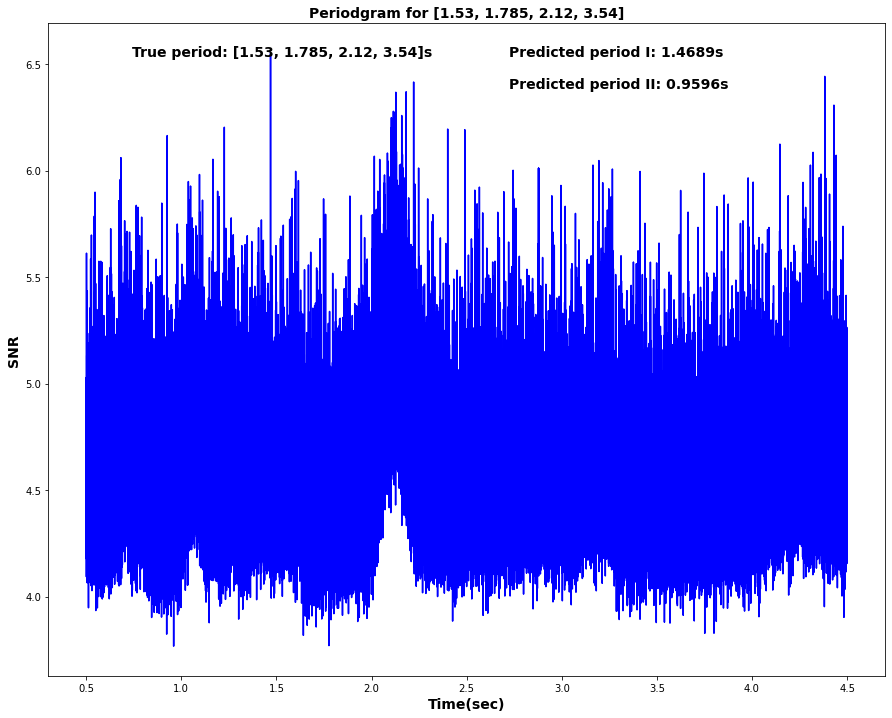

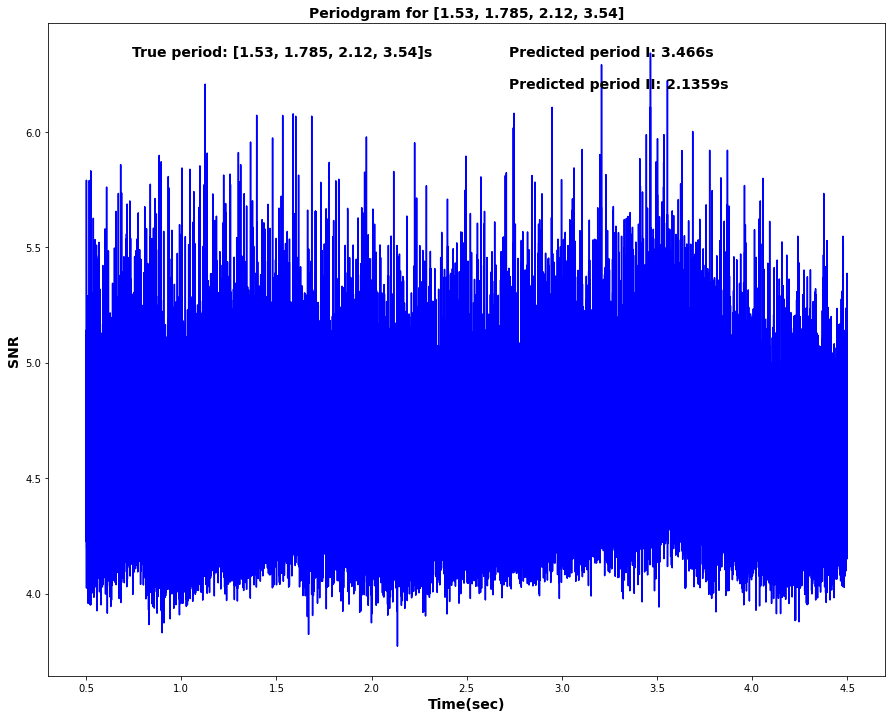

In [16]:
lbound_period = 0.5 
ubound_period = 4.5
dpth = '/Users/manojkhadka/research/claudeChatgptversion/mock_pulsar_data/'
save_to = '/Users/manojkhadka/research/FFA_research/save_results/'

file_list = ['period_1.53sec_dty_cycl0.1_ang_accl_0_.txt', 'period_1.785sec_dty_cycl0.1_ang_accl_0_.txt',
'period_2.12sec_dty_cycl0.1_ang_accl_0_.txt', 'period_3.541sec_dty_cycl0.1_ang_accl_0_.txt']


final_record_file = save_to+'exclude_20_percent_ofmedn.txt'
with open(final_record_file, 'w') as file:
    file.write("True Period\t\tPredicted period I\t\tPredicted period II\n")

    for i1 in np.arange(len(file_list)):
        filePath = dpth+file_list[i1]
#         true_period = grab_actual_period(filePath)
        true_period = [1.53, 1.785, 2.12, 3.54]
        fileName = save_to+'test_stats_'+str(true_period[i1])+'.txt'
        test_dataset, datResn = read_datafile(filePath)
        ffa_alg_launch(test_dataset, fileName, datResn, lbound_period, ubound_period)
        bestP1, bestP2 = grab_predictedperiod(fileName)
        file.write(str(true_period)+'\t\t'+str(bestP1)+'\t\t'+str(bestP2)+'\n')
        dat_frm = pd.read_csv(fileName, sep='\t\t', header=0)
        x_data = dat_frm['time']
        y_data = dat_frm['SNR_value']
        periodogram_maker(true_period, x_data, y_data, save_to)